# 01 · Exploratory Data Analysis: who leaves the bank?

**Business question:** ABC Multistate Bank loses about 1 in 5 customers. Before building a model, we want to know
*which customer segments churn most* and *which signals are statistically meaningful*, so retention teams can act on them.

**Data:** 10,000 customers, 12 columns (Kaggle *Bank Customer Churn Dataset*). Target `churn = 1` means the customer left.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from churn.data import FIGURES_DIR, TARGET, AGE_BINS, AGE_LABELS, load_data

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=0.95)
CHURN, STAY = "#C0392B", "#2E86C1"
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Load and check the data

In [2]:
df = load_data()
print(f"Rows: {len(df):,} | Columns: {df.shape[1]} | Missing values: {df.isna().sum().sum()}")
print(f"Overall churn rate: {df[TARGET].mean():.1%}")
df.head()

Rows: 10,000 | Columns: 11 | Missing values: 0
Overall churn rate: 20.4%


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
credit_score,10000.000,650.529,96.653,350.000,584.000,652.000,718.000,850.000
age,10000.000,38.922,10.488,18.000,32.000,37.000,44.000,92.000
tenure,10000.000,5.013,2.892,0.000,3.000,5.000,7.000,10.000
balance,10000.000,76485.889,62397.405,0.000,0.000,97198.540,127644.240,250898.090
products_number,10000.000,1.530,0.582,1.000,1.000,1.000,2.000,4.000
credit_card,10000.000,0.706,0.456,0.000,0.000,1.000,1.000,1.000
active_member,10000.000,0.515,0.500,0.000,0.000,1.000,1.000,1.000
estimated_salary,10000.000,100090.240,57510.493,11.580,51002.110,100193.915,149388.247,199992.480
churn,10000.000,0.204,0.403,0.000,0.000,0.000,0.000,1.000


The data is clean: no missing values and one row per customer. The target is imbalanced (~20% churners),
so later we evaluate models with ROC-AUC, precision and recall, not accuracy alone.

## 2. Churn rate by customer segment

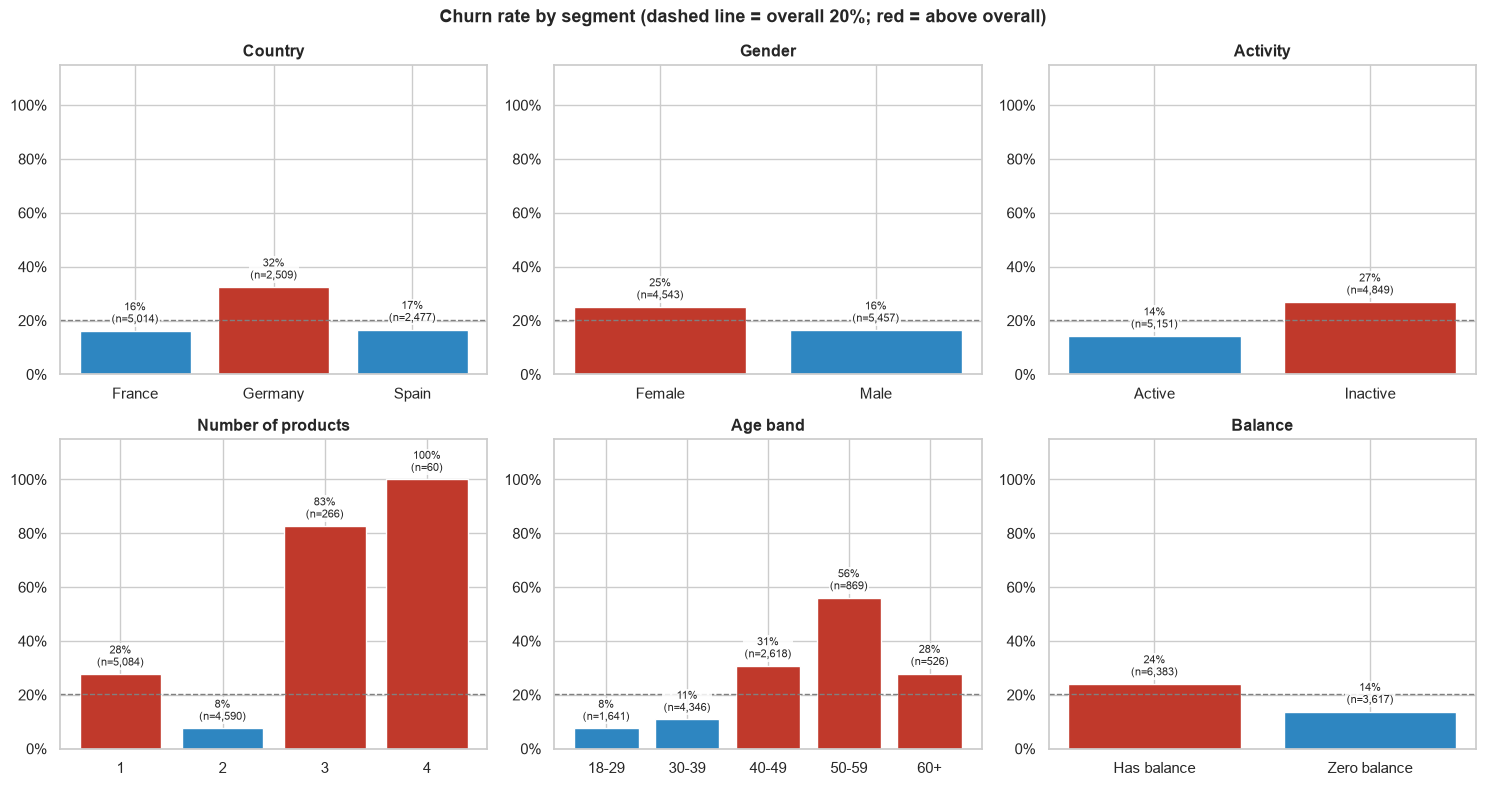

In [4]:
seg = df.assign(
    age_band=pd.cut(df["age"], AGE_BINS, labels=AGE_LABELS),
    activity=df["active_member"].map({1: "Active", 0: "Inactive"}),
    balance_status=np.where(df["balance"] == 0, "Zero balance", "Has balance"),
)
segments = {
    "Country": "country", "Gender": "gender", "Activity": "activity",
    "Number of products": "products_number", "Age band": "age_band", "Balance": "balance_status",
}
overall = df[TARGET].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (title, col) in zip(axes.flat, segments.items()):
    rates = seg.groupby(col, observed=True)[TARGET].agg(["mean", "size"])
    colors = [CHURN if r > overall else STAY for r in rates["mean"]]
    ax.bar(rates.index.astype(str), rates["mean"], color=colors)
    ax.axhline(overall, ls="--", c="grey", lw=1)
    for i, (r, n) in enumerate(zip(rates["mean"], rates["size"])):
        ax.text(i, r + 0.02, f"{r:.0%}\n(n={n:,})", ha="center", va="bottom", fontsize=8,
                bbox=dict(facecolor="white", edgecolor="none", pad=1, alpha=0.85))
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
fig.suptitle(f"Churn rate by segment (dashed line = overall {overall:.0%}; red = above overall)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "churn_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

**What stands out**

| Segment | Churn rate | Reading |
|---|---|---|
| Germany | **32.4%** | 2x France (16.2%) and Spain (16.7%) |
| Female | 25.1% | vs. 16.5% for male customers |
| Inactive members | 26.9% | vs. 14.3% for active members; **48.5%** of customers are inactive |
| 1 product | 27.7% | 2 products is the sweet spot (**7.6%**) |
| 3 or 4 products | **82.7% / 100%** | small group (326 customers) but almost all leave |
| Age 50-59 | **56.0%** | churn rises sharply after 40; under 40 stays near 10% |
| Zero balance | 13.8% | customers holding a balance churn more (24.1%) |

## 3. Numeric features: churners vs. stayers

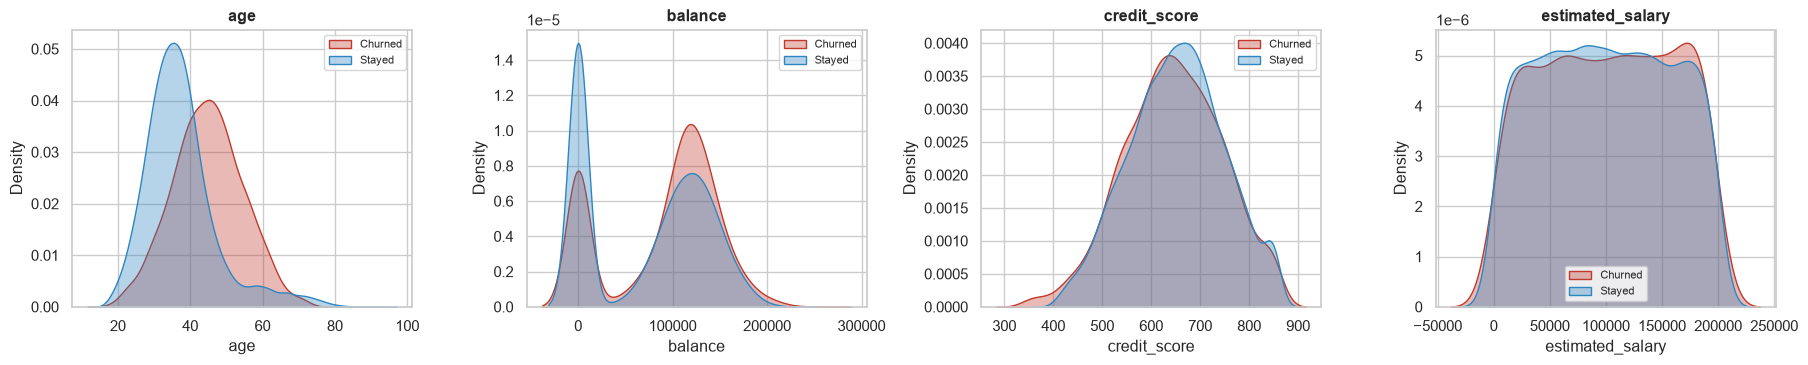

,age,balance,credit_score,estimated_salary,tenure
churn,,,,,
Stayed,37.408,72745.297,651.853,99738.392,5.033
Churned,44.838,91108.539,645.351,101465.678,4.933


In [5]:
num_cols = ["age", "balance", "credit_score", "estimated_salary"]
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, fill=True, alpha=0.35,
                palette={0: STAY, 1: CHURN}, ax=ax)
    ax.set_title(col, fontweight="bold")
    ax.legend(["Churned", "Stayed"], fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

df.groupby(TARGET)[num_cols + ["tenure"]].mean().rename(index={0: "Stayed", 1: "Churned"})

## 4. Which differences are statistically significant?

In [6]:
from scipy import stats

rows = []
for col in ["age", "balance", "credit_score", "estimated_salary", "tenure"]:
    p = stats.ttest_ind(df.loc[df[TARGET] == 1, col], df.loc[df[TARGET] == 0, col], equal_var=False).pvalue
    rows.append({"feature": col, "test": "Welch t-test", "p_value": p})
for col in ["country", "gender", "active_member", "products_number", "credit_card"]:
    p = stats.chi2_contingency(pd.crosstab(df[col], df[TARGET])).pvalue
    rows.append({"feature": col, "test": "Chi-square", "p_value": p})

tests = pd.DataFrame(rows).sort_values("p_value")
tests["significant (p < 0.05)"] = tests["p_value"] < 0.05
tests.style.format({"p_value": "{:.2e}"})

,feature,test,p_value,significant (p < 0.05)
8,products_number,Chi-square,0.00e+00,True
0,age,Welch t-test,4.71e-179,True
5,country,Chi-square,3.83e-66,True
7,active_member,Chi-square,8.79e-55,True
1,balance,Welch t-test,6.32e-35,True
6,gender,Chi-square,2.25e-26,True
2,credit_score,Welch t-test,8.46e-03,True
4,tenure,Welch t-test,1.66e-01,False
3,estimated_salary,Welch t-test,2.29e-01,False
9,credit_card,Chi-square,4.92e-01,False


Age, product count, country, activity, gender and balance are strongly associated with churn.
**Tenure, estimated salary and credit-card ownership are not significant**, so offering a credit card or relying on
salary data is unlikely to help retention.

## 5. Interaction: activity x number of products

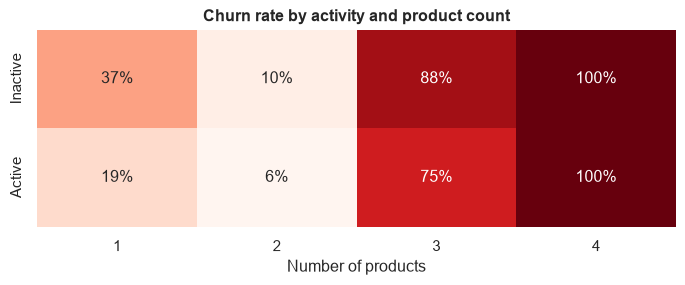

In [7]:
pivot = df.pivot_table(index="active_member", columns="products_number", values=TARGET, aggfunc="mean")
pivot.index = ["Inactive", "Active"]
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="Reds", cbar=False, ax=ax)
ax.set_xlabel("Number of products")
ax.set_ylabel("")
ax.set_title("Churn rate by activity and product count", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "activity_products_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Inactive single-product customers churn at **36.7%**, while active customers with 2 products churn at only **5.6%**.
Moving a customer from one product to two, and keeping them active, is the clearest retention lever in the data.

## Key takeaways for the retention team

1. **Prioritize Germany**: churn is twice the rate of other markets and German customers hold ~2x the balance of
   French and Spanish customers, so each loss costs more.
2. **Re-activate inactive members**: they are 48.5% of the base and churn nearly twice as often as active members.
3. **Grow single-product customers to exactly two products**, and review why 3-4 product customers almost all leave
   (possible mis-selling or product-bundle issues).
4. **Watch customers aged 40-60**: the highest-risk age group, especially 50-59 (56% churn).
5. **Do not rely on tenure, salary or credit-card ownership**: they show no significant link to churn.